In [24]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc
from sklearn.manifold import TSNE
from tensorflow.keras.models import load_model, Model

In [34]:
FOLDS_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\data\imgData\prepImg\Folds"
MODEL_DIR = r"C:\Users\Yasindu\Desktop\Stuff\1.SLIIT\Research\Project\infant-growth-monitoring-system\mlModels\autisumDetect\sector1\Best_Models"
SEED = 123
OPTIMIZED_THRESHOLD = 0.10

In [35]:
# Using the CURRENT_FOLD or hardcoding to 4 since your model is Fold 4
fold_to_visualize = 4 
val_paths_fold4 = np.load(os.path.join(FOLDS_DIR, f'fold_{fold_to_visualize}_val_paths.npy'), allow_pickle=True)
val_labels_fold4 = np.load(os.path.join(FOLDS_DIR, f'fold_{fold_to_visualize}_val_labels.npy'), allow_pickle=True)

In [36]:
def process_eval_data(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    
    # VGG-Face Preprocessing
    img = img[..., ::-1] # RGB to BGR
    mean = [93.5940, 104.7624, 129.1863]
    img = img - mean
    
    # Logic: Autistic=1, Non_Autistic=0
    target_label = 1.0 - tf.cast(label, tf.float32)
    return img, target_label

# Storage for results
fold_accuracies = []
all_true_labels = []
all_pred_labels = []

print("Starting Step 1 & 2: Aggregated Evaluation...")

Starting Step 1 & 2: Aggregated Evaluation...


In [37]:
def process_fold_data_vis(file_path, label, augment=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    
    # VGG-Face Preprocessing: BGR conversion and Mean Subtraction
    img = img[..., ::-1] # RGB to BGR
    mean = [93.5940, 104.7624, 129.1863]
    img = img - mean

    # We skip augmentation for visualization to see the raw feature space
    
    # Map labels: Autistic=1, Non_Autistic=0
    target_label = 1.0 - tf.cast(label, tf.float32)
    return img, {
        'classification_output': target_label, 
        'asd_feature_vector': target_label
    }

Loading Permanent Test Set...
Evaluating Best Model: fold_4_best.h5


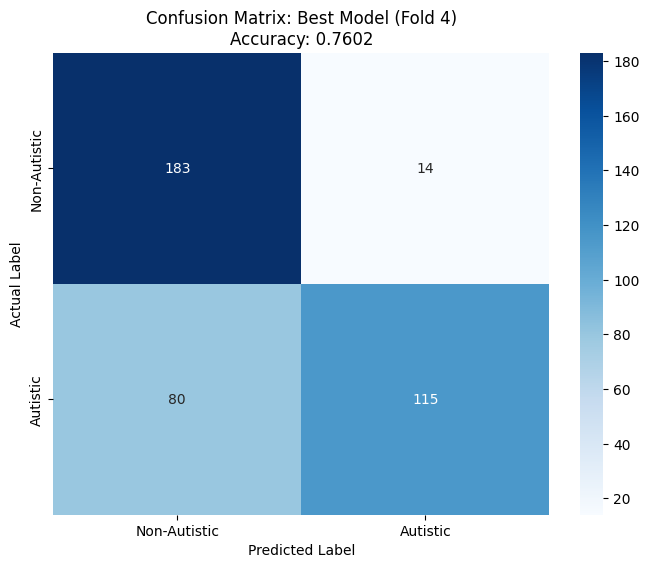


--- Detailed Classification Report ---
              precision    recall  f1-score   support

Non-Autistic       0.70      0.93      0.80       197
    Autistic       0.89      0.59      0.71       195

    accuracy                           0.76       392
   macro avg       0.79      0.76      0.75       392
weighted avg       0.79      0.76      0.75       392



In [38]:
# Load the best performing model (Fold 4)
best_model_path = os.path.join(MODEL_DIR, 'fold_4_best.h5')

# --- 2. LOAD DATA ---
print("Loading Permanent Test Set...")
test_paths = np.load(os.path.join(FOLDS_DIR, 'permanent_test_paths.npy'), allow_pickle=True)
test_labels = np.load(os.path.join(FOLDS_DIR, 'permanent_test_labels.npy'), allow_pickle=True)

# Dataset preparation
test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
          .map(process_eval_data) # Re-use your VGG-Face preprocessing function
          .batch(4))

# --- 3. MODEL PREDICTION ---
tf.keras.backend.clear_session()
print(f"Evaluating Best Model: {os.path.basename(best_model_path)}")
model = load_model(best_model_path, compile=False)

y_true = []
y_pred_probs = []

for imgs, labels in test_ds:
    preds, _ = model.predict(imgs, verbose=0)
    y_pred_probs.extend(preds.flatten())
    y_true.extend(labels.numpy().flatten())

# Convert to binary labels using default 0.5 threshold
y_true = np.array(y_true).astype(int)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# --- 4. VISUALIZE CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Autistic', 'Autistic'],
            yticklabels=['Non-Autistic', 'Autistic'])

plt.title(f'Confusion Matrix: Best Model (Fold 4)\nAccuracy: {np.mean(y_true == y_pred):.4f}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Print detailed report for confirmation
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Non-Autistic', 'Autistic']))

In [39]:
# 1. Define the range of thresholds to test
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

print("Analyzing Thresholds for Fold 4...")

for t in thresholds:
    # Apply threshold to the probability predictions
    y_pred_t = (np.array(y_pred_probs) > t).astype(int)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
    precision_asd = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_asd = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F2-Score (Weights Recall twice as much as Precision)
    f2 = (5 * precision_asd * recall_asd) / (4 * precision_asd + recall_asd) if (precision_asd + recall_asd) > 0 else 0
    
    results.append({
        'Threshold': round(t, 2),
        'True Positives (ASD)': tp,
        'False Negatives (Missed)': fn,
        'Precision (ASD)': round(precision_asd, 3),
        'Recall (ASD)': round(recall_asd, 3),
        'F2-Score': round(f2, 3)
    })

# Display results as a Table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Identify the Best Threshold for Recall/F2
best_t = results_df.loc[results_df['F2-Score'].idxmax()]
print(f"\nRecommended Threshold based on F2-Score: {best_t['Threshold']}")

Analyzing Thresholds for Fold 4...
 Threshold  True Positives (ASD)  False Negatives (Missed)  Precision (ASD)  Recall (ASD)  F2-Score
      0.10                   155                        40            0.767         0.795     0.789
      0.15                   146                        49            0.781         0.749     0.755
      0.20                   140                        55            0.782         0.718     0.730
      0.25                   137                        58            0.811         0.703     0.722
      0.30                   128                        67            0.826         0.656     0.684
      0.35                   122                        73            0.841         0.626     0.659
      0.40                   118                        77            0.861         0.605     0.643
      0.45                   117                        78            0.886         0.600     0.641
      0.50                   115                        80       

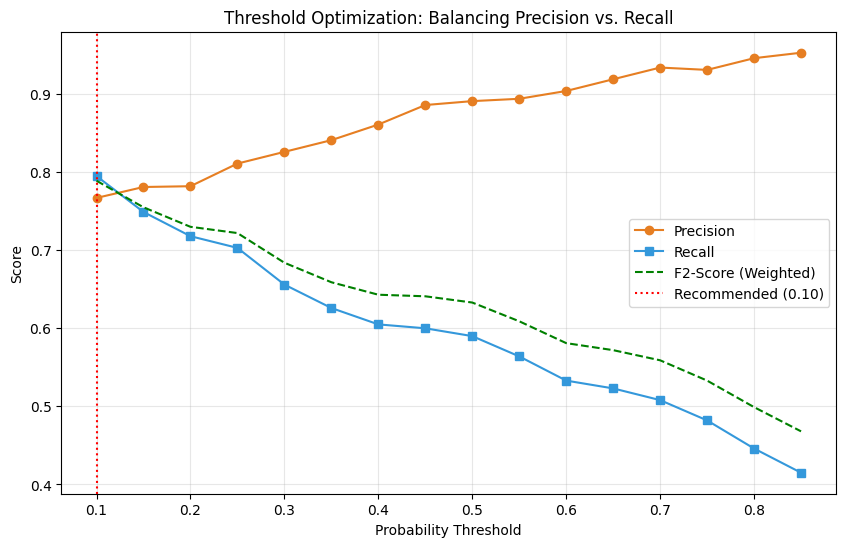

In [40]:

plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision (ASD)'], label='Precision', marker='o', color='#e67e22')
plt.plot(results_df['Threshold'], results_df['Recall (ASD)'], label='Recall', marker='s', color='#3498db')
plt.plot(results_df['Threshold'], results_df['F2-Score'], label='F2-Score (Weighted)', linestyle='--', color='green')

plt.axvline(x=0.10, color='red', linestyle=':', label='Recommended (0.10)')
plt.title('Threshold Optimization: Balancing Precision vs. Recall')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

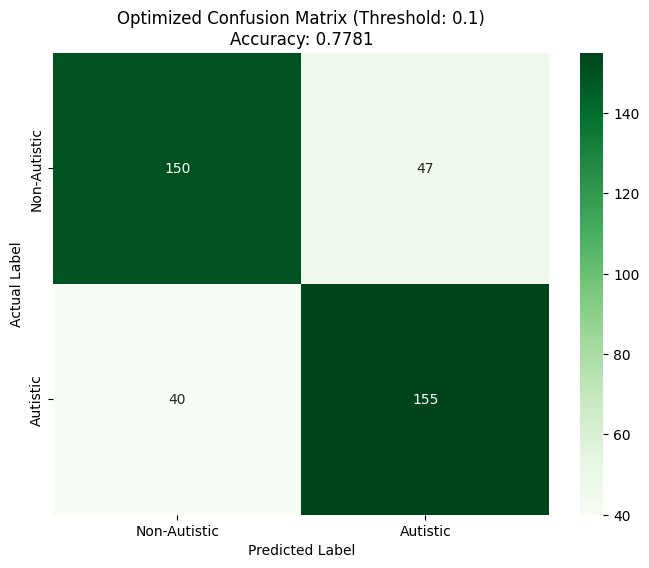


--- Detailed Classification Report (Threshold: 0.1) ---
              precision    recall  f1-score   support

Non-Autistic       0.79      0.76      0.78       197
    Autistic       0.77      0.79      0.78       195

    accuracy                           0.78       392
   macro avg       0.78      0.78      0.78       392
weighted avg       0.78      0.78      0.78       392



In [41]:
# --- 4. VISUALIZE CONFUSION MATRIX (ADJUSTED THRESHOLD) ---
# Apply the optimized threshold found in the F2-Score analysis
OPTIMIZED_THRESHOLD = 0.10

y_true = np.array(y_true).astype(int)
# Instead of > 0.5, we use our optimized value
y_pred_optimized = (np.array(y_pred_probs) > OPTIMIZED_THRESHOLD).astype(int)

# Calculate the new confusion matrix
cm_optimized = confusion_matrix(y_true, y_pred_optimized)
new_accuracy = np.mean(y_true == y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', # Changed color to Green to distinguish
            xticklabels=['Non-Autistic', 'Autistic'],
            yticklabels=['Non-Autistic', 'Autistic'])

plt.title(f'Optimized Confusion Matrix (Threshold: {OPTIMIZED_THRESHOLD})\nAccuracy: {new_accuracy:.4f}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Print detailed report for the adjusted threshold
print(f"\n--- Detailed Classification Report (Threshold: {OPTIMIZED_THRESHOLD}) ---")
print(classification_report(y_true, y_pred_optimized, target_names=['Non-Autistic', 'Autistic']))

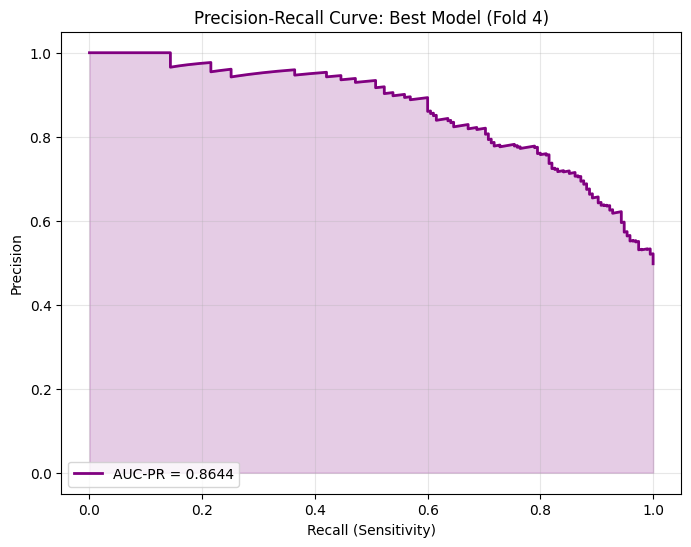

The AUC-PR for Fold 4 is: 0.8644


In [42]:
# 1. Calculate the Precision-Recall pairs for all thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)

# 2. Calculate the Area Under the Curve (AUC-PR)
auc_pr = auc(recall, precision)

# 3. Plot the Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'AUC-PR = {auc_pr:.4f}')
plt.fill_between(recall, precision, alpha=0.2, color='purple')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Best Model (Fold 4)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"The AUC-PR for Fold 4 is: {auc_pr:.4f}")

Extracting feature vectors for visualization...


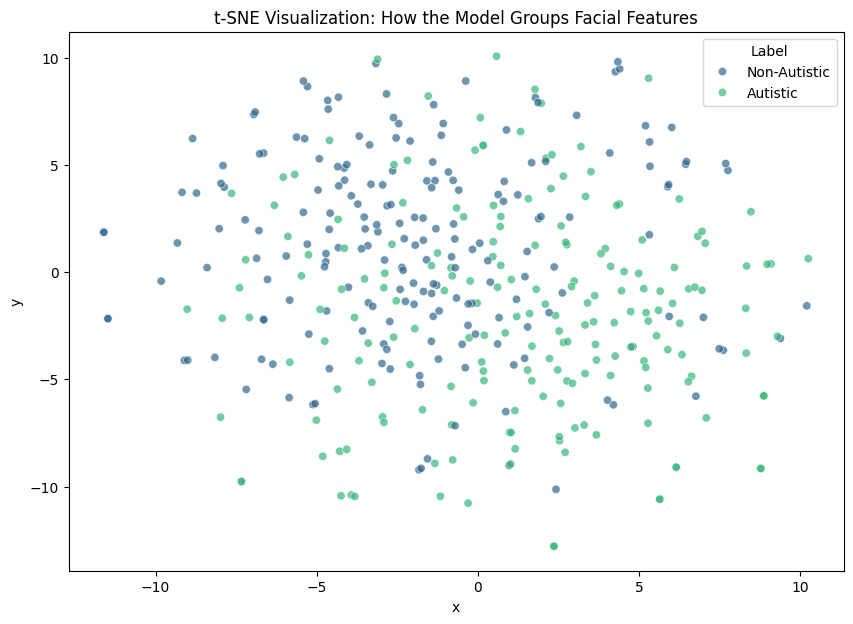

In [43]:
# --- Ensure these paths are loaded ---
test_paths = np.load(os.path.join(FOLDS_DIR, 'permanent_test_paths.npy'), allow_pickle=True)
test_labels = np.load(os.path.join(FOLDS_DIR, 'permanent_test_labels.npy'), allow_pickle=True)

# --- Re-define the dataset variable 'test_ds' ---
test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
          .map(process_eval_data) 
          .batch(4))
print("Extracting feature vectors for visualization...")
all_features = []
all_labels_tsne = []
for images, labels in test_ds: # Matched to your 'test_ds'
    # Use the second output of your model: [preds, features]
    _, features = model.predict(images, verbose=0) # Matched to your 'model'
    all_features.append(features)
    # Labels in your test_ds are direct tensors, not a dictionary
    all_labels_tsne.extend(labels.numpy().flatten()) 

all_features = np.concatenate(all_features, axis=0)
all_labels_tsne = np.array(all_labels_tsne)

# 2. Run t-SNE (Using your SEED = 123)
tsne = TSNE(n_components=2, random_state=SEED)
low_dim_features = tsne.fit_transform(all_features)

# 3. Plot the Clusters
plt.figure(figsize=(10, 7))
df_tsne = pd.DataFrame({
    'x': low_dim_features[:, 0],
    'y': low_dim_features[:, 1],
    'Label': ['Autistic' if l == 1 else 'Non-Autistic' for l in all_labels_tsne]
})

sns.scatterplot(data=df_tsne, x='x', y='y', hue='Label', palette='viridis', alpha=0.7)
plt.title('t-SNE Visualization: How the Model Groups Facial Features')
plt.show()